Question 1:  What is Boosting in Machine Learning? Explain how it improves weak learners ?

Answer-1 : Boosting is an ensemble modeling technique in machine learning that attempts to build a strong predictive model from the mistakes of several weaker models.

Unlike methods that build models in isolation (like Bagging/Random Forests), Boosting builds models sequentially, with each new model directly attempting to fix the errors of the previous one.

What are "Weak Learners"? :

A weak learner is a simple model that performs only slightly better than random guessing.
 - Example: In a binary classification problem (Yes/No), a random guess would be 50% accurate. A weak learner might be 55% or 60% accurate.
 - Common Type: The most common weak learner used in boosting is a "Decision Stump"—a decision tree with only one split (one root node and two leaves).

How Boosting Improves Weak Learners :

Boosting turns these weak learners into a strong learner through an iterative process. Here is the mechanism:
1. Sequential Training : Boosting trains models one after another in a sequence, rather than all at once.
   - Model 1 is trained on the raw data.
   - Model 2 is trained effectively on the "mistakes" of Model 1.
   - Model 3 is trained on the "mistakes" of Model 1 + Model 2.
2. Focus on Errors (Reweighting) : This is the key step. After a weak learner makes a prediction, the algorithm evaluates where it went wrong.
   - Reweighting Data: If a data point was classified incorrectly, the algorithm increases its "weight." This makes that specific data point more important for the next weak learner.
   - The Result: The next model is forced to focus specifically on the hard-to-predict cases that the previous models missed.
3. Weighted Combination : Once the sequence is complete, the weak learners are combined to make a final prediction. However, they are not treated equally.
 - Models that performed well (low error) are given more "say" (higher weight) in the final decision.
 - Models that performed poorly are given less say.

Question 2: What is the difference between AdaBoost and Gradient Boosting in terms of how models are trained?

Answer-2 : Both AdaBoost (Adaptive Boosting) and Gradient Boosting build weak learners sequentially to create a strong model. However, the key difference lies in how they identify and correct the shortcomings of the previous models.

1. AdaBoost: Up-weighting Misclassified Data :

AdaBoost focuses on specific data points that are difficult to classify.
 - Mechanism: It assigns a "weight" to every observation in the dataset. Initially, all weights are equal.
 - The Update: After a weak learner is trained, AdaBoost checks which data points were misclassified.
 - The Correction: It increases the weight of the misclassified points and decreases the weight of the correctly classified ones.
 - Result: The next model in the sequence is forced to pay more attention to the "hard" examples (the ones with high weights) because getting them wrong will result in a higher error penalty.

2. Gradient Boosting: Fitting the Residuals :

Gradient Boosting focuses on the magnitude of the error (the residual) rather than specific data points.

 - Mechanism: It does not change the weights of the data points. Instead, it looks at the difference between the predicted value and the actual value. This difference is called the residual.
 - The Update: The next model is not trained to predict the target label (Y). Instead, it is trained to predict the residual error of the previous model.
 - The Correction: By adding the predicted residual to the previous prediction, the model nudges the result closer to the true value. Effectively, it performs gradient descent on the loss function.
 - Result: Each new model acts as a specific "correction factor" for the overall prediction.

Question 3: How does regularization help in XGBoost?

Answer-3 :Regularization in XGBoost is a technique used to prevent overfitting (when the model memorizes the training data noise instead of learning the actual patterns).

While standard Gradient Boosting controls complexity mainly through tree depth and learning rate, XGBoost includes regularization terms directly in its objective function. This makes it more conservative and robust.

The Objective Function :

In XGBoost, the goal is to minimize an objective function that has two parts:

Obj=Loss Function+Regularization Term (Ω)

The regularization term (Ω) penalizes the complexity of the model in three specific ways:

1. Gamma (γ): Minimum Loss Reduction (Pruning) :

This parameter controls the structure of the tree.
 - How it works: When XGBoost considers splitting a leaf node, it calculates if the split reduces the loss. However, XGBoost imposes a penalty (γ) for adding a new leaf.
 - The Rule: If the Gain from the split is less than γ, the split is discarded.
 - Effect: This acts as a "pseudo-regularization" or automatic tree pruning. It stops the tree from growing too deep if the split doesn't contribute significantly to the model's accuracy

2. Lambda (λ): L2 Regularization (Ridge) :

This parameter controls the weights (scores) of the leaves.

 - How it works: It adds a penalty equivalent to the square of the leaf weights (λ∑w2).
 - Effect: This forces the leaf scores to be smaller and smoother. Large weights usually indicate that the model is relying too heavily on a specific rule; shrinking them prevents the model from being "too confident" and sensitive to individual data points.

3. Alpha (α): L1 Regularization (Lasso) :

Like Lambda, this also controls leaf weights but uses the absolute value (α∑∣w∣).
 - How it works: It penalizes the absolute value of the weights.
 - Effect: L1 regularization encourages sparsity. It can force some leaf weights to become exactly zero, effectively ignoring those leaves. This is useful for feature selection in very high-dimensional data.

Question 4: Why is CatBoost considered efficient for handling categorical data?

Answer-4 : CatBoost (short for Categorical Boosting) is specifically engineered to handle categorical features directly, without requiring extensive preprocessing like One-Hot Encoding.

Its efficiency comes from a unique method called Ordered Target Statistics that solves the data leakage problems found in other algorithms.

1. Ordered Target Statistics (Target Encoding) :

Most algorithms require you to convert categories (like "Red", "Blue") into numbers. A common method is Target Encoding, where you replace "Red" with the average target value for all "Red" items.
 - The Problem (Data Leakage): In standard target encoding, the target value of a specific row is used to calculate the average for its own category. This causes "target leakage"—the model "sees" the answer during training and overfits, failing on new data.
 - The CatBoost Solution: CatBoost uses Ordered Target Statistics. It randomly shuffles the rows and calculates the average target for a category using only the rows that appear before the current one in the shuffled sequence.
   - This simulates a real-time scenario where you rely only on past data, preventing overfitting.

2. Handling High Cardinality (Too many categories) :

If you have a feature with thousands of unique categories (e.g., Zip Codes or User IDs), standard One-Hot Encoding creates a massive, sparse matrix with thousands of new columns. This consumes huge amounts of memory and slows down training (the "Curse of Dimensionality").
 - Efficiency: Because CatBoost uses statistics (numbers) to represent these categories rather than creating new columns, it keeps the dataset size manageable and training fast, even with high-cardinality features.

3. Combination of Features :

CatBoost automatically looks for interactions between categorical features.
 - Example: It might combine "Color=Red" and "Size=Large" into a single new feature "Red_Large" if it discovers that the combination is more predictive than the individual features. It does this greedily during tree construction, saving you the effort of manual feature engineering.

4. Symmetric (Oblivious) Trees :

Unlike XGBoost or LightGBM, which grow unbalanced trees, CatBoost builds symmetric trees.
 - This means the same split condition is used for all nodes at the same depth.
 - Benefit: This structure allows for extremely fast execution at prediction time because it simplifies the memory access patterns for the CPU.




In [3]:
# Question 5: What are some real-world applications where boosting techniques are preferred over bagging methods?
# ● Use sklearn.datasets.load_breast_cancer() for classification tasks.
# ● Use sklearn.datasets.fetch_california_housing() for regression tasks.
# Answer-5 : Boosting is generally preferred over Bagging in real-world applications where high accuracy is the priority and the data is structured (tabular) but potentially unbalanced.

# While Bagging (e.g., Random Forest) focuses on stability and reducing variance (overfitting), Boosting (e.g., Gradient Boosting, XGBoost) focuses on reducing bias (underfitting) by aggressively learning from mistakes.

# Real-World Applications :
# 1. Medical Diagnosis (Classification) :
# - Scenario: Detecting rare diseases like cancer.
# - Why Boosting: In medical datasets, the "positive" cases (disease) are often rare and subtle. Boosting algorithms can be tuned to prioritize these hard-to-classify examples, effectively minimizing False Negatives (missing a sick patient), which is critical in healthcare.
# - Dataset: sklearn.datasets.load_breast_cancer()
# 2. Real Estate Valuation (Regression) :
# - Scenario: Zillow-style home price estimation.
# - Why Boosting: Housing prices depend on complex interactions (e.g., "Location" is important, but "Location + High School Rating" is even more important). Boosting excels at capturing these non-linear feature interactions, often yielding a lower Mean Squared Error (MSE) than bagging methods.
# - Dataset: sklearn.datasets.fetch_california_housing()
# 3. Credit Risk Scoring (Financial Tech) :
# - Scenario: Determining if a user will default on a loan.
# - Why Boosting: Similar to medical diagnosis, defaults are the minority class. Gradient Boosting is the industry standard (often using XGBoost or LightGBM) because it pushes the model to distinguish between "risky" and "very risky" applicants with high precision.
# Python Implementation :
# Below is a comparison of Boosting (Gradient Boosting) vs. Bagging (Random Forest) using the datasets you requested.
import pandas as pd
from sklearn.datasets import load_breast_cancer, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import accuracy_score, mean_squared_error

# ==========================================
# PART 1: CLASSIFICATION (Breast Cancer)
# Application: Medical Diagnosis
# ==========================================
print("--- Classification: Breast Cancer Diagnosis ---")

# 1. Load Data
data_cancer = load_breast_cancer()
X_c, y_c = data_cancer.data, data_cancer.target

# 2. Split Data (80% Train, 20% Test)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_c, y_c, test_size=0.2, random_state=42)

# 3. Bagging: Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_c, y_train_c)
rf_acc = accuracy_score(y_test_c, rf_clf.predict(X_test_c))

# 4. Boosting: Gradient Boosting
gb_clf = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gb_clf.fit(X_train_c, y_train_c)
gb_acc = accuracy_score(y_test_c, gb_clf.predict(X_test_c))

print(f"Bagging (Random Forest) Accuracy: {rf_acc:.4f}")
print(f"Boosting (Gradient Boosting) Accuracy: {gb_acc:.4f}")
print("-" * 40)


# ==========================================
# PART 2: REGRESSION (California Housing)
# Application: Real Estate Pricing
# ==========================================
print("\n--- Regression: California Housing Prices ---")

# 1. Load Data
data_housing = fetch_california_housing()
X_h, y_h = data_housing.data, data_housing.target

# 2. Split Data
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_h, y_h, test_size=0.2, random_state=42)

# 3. Bagging: Random Forest
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train_h, y_train_h)
rf_mse = mean_squared_error(y_test_h, rf_reg.predict(X_test_h))

# 4. Boosting: Gradient Boosting
gb_reg = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gb_reg.fit(X_train_h, y_train_h)
gb_mse = mean_squared_error(y_test_h, gb_reg.predict(X_test_h))

print(f"Bagging (Random Forest) MSE: {rf_mse:.4f}")
print(f"Boosting (Gradient Boosting) MSE: {gb_mse:.4f}")
print("(Lower MSE is better)")

# Key Takeaways from the Code :
# - Classification: You will often see Boosting achieve slightly higher accuracy or recall because it iteratively fixes the misclassified cancer cases that the Random Forest might gloss over.
# - Regression: Boosting typically achieves a lower Mean Squared Error (MSE) on housing data because it can fine-tune its predictions for outlier prices (e.g., extremely expensive houses) better than the averaging approach of Random Forest.

--- Classification: Breast Cancer Diagnosis ---
Bagging (Random Forest) Accuracy: 0.9649
Boosting (Gradient Boosting) Accuracy: 0.9561
----------------------------------------

--- Regression: California Housing Prices ---
Bagging (Random Forest) MSE: 0.2554
Boosting (Gradient Boosting) MSE: 0.2940
(Lower MSE is better)


In [4]:
# Question 6: Write a Python program to:
# ● Train an AdaBoost Classifier on the Breast Cancer dataset
# ● Print the model accuracy
# Answer-6 :
# Import necessary libraries
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Load the dataset
data = load_breast_cancer()
X = data.data  # Features
y = data.target  # Labels (Malignant/Benign)

# 2. Split the data into training and testing sets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize the AdaBoost Classifier
# n_estimators=50: The maximum number of weak learners (stumps) to train
clf = AdaBoostClassifier(n_estimators=50, random_state=42)

# 4. Train the model
clf.fit(X_train, y_train)

# 5. Make predictions on the test set
y_pred = clf.predict(X_test)

# 6. Calculate and print the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"AdaBoost Model Accuracy: {accuracy:.4f}")

AdaBoost Model Accuracy: 0.9649


In [5]:
# Question 7:  Write a Python program to:
# ● Train a Gradient Boosting Regressor on the California Housing dataset
# ● Evaluate performance using R-squared score
# Answer-7 :
# Import necessary libraries
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# 1. Load the dataset
# This dataset contains housing data (e.g., median income, house age)
# to predict median house value.
housing = fetch_california_housing()
X = housing.data
y = housing.target

# 2. Split the data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize the Gradient Boosting Regressor
# n_estimators=100: Number of boosting stages to perform
# learning_rate=0.1: Shrinks the contribution of each tree by 0.1
# max_depth=3: Limits the depth of individual regression trees
gbr = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# 4. Train the model
gbr.fit(X_train, y_train)

# 5. Make predictions
y_pred = gbr.predict(X_test)

# 6. Evaluate performance using R-squared score
r2 = r2_score(y_test, y_pred)

print(f"Gradient Boosting Regressor R-squared Score: {r2:.4f}")

Gradient Boosting Regressor R-squared Score: 0.7756


In [10]:
# Question 8: Write a Python program to:
# ● Train an XGBoost Classifier on the Breast Cancer dataset
# ● Tune the learning rate using GridSearchCV
# ● Print the best parameters and accuracy
# Answer-8 :
import xgboost as xgb
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score

# 1. Load the dataset
data = load_breast_cancer()
X = data.data
y = data.target

# 2. Split the data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Define the model
xgb_clf = xgb.XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='logloss', random_state=42)

# 4. Define the parameter grid
# We will test 5 different learning rates
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3]
}

# 5. Initialize GridSearchCV
# cv=5: Uses 5-fold Cross-Validation
grid_search = GridSearchCV(estimator=xgb_clf, param_grid=param_grid, cv=5, scoring='accuracy')

# 6. Train with Grid Search (Tuning)
print("Tuning learning rate...")
grid_search.fit(X_train, y_train)

# 7. Print the best parameters found
print(f"Best Learning Rate: {grid_search.best_params_['learning_rate']}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

# 8. Evaluate on the Test Set using the best model
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Test Set Accuracy: {test_accuracy:.4f}")

Tuning learning rate...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:24:01] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:24:02] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:24:06] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:24:07] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:24:08] WARNING: /w

Best Learning Rate: 0.2
Best Cross-Validation Accuracy: 0.9670
Test Set Accuracy: 0.9561


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:24:11] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:24:11] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.7 MB/s eta 0:00:00


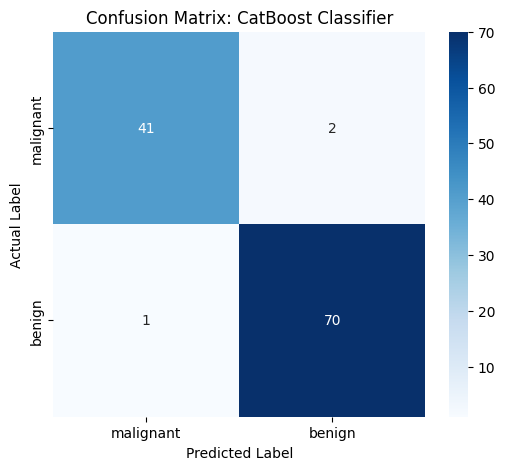

In [9]:
# Question 9: Write a Python program to:
# ● Train a CatBoost Classifier
# ● Plot the confusion matrix using seaborn
# Answer-9 :
import matplotlib.pyplot as plt
import seaborn as sns
# Install catboost if it's not already installed
!pip install catboost
from catboost import CatBoostClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# 1. Load the dataset (Breast Cancer data)
data = load_breast_cancer()
X = data.data
y = data.target
target_names = data.target_names  # ['malignant', 'benign']

# 2. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and Train CatBoost
# verbose=0 suppresses the iteration logs for cleaner output
clf = CatBoostClassifier(iterations=100, learning_rate=0.1, depth=3, verbose=0)
clf.fit(X_train, y_train)

# 4. Make Predictions
y_pred = clf.predict(X_test)

# 5. Create the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# 6. Plot using Seaborn
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix: CatBoost Classifier')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
# Question 10: You're working for a FinTech company trying to predict loan default using
# customer demographics and transaction behavior.
# The dataset is imbalanced, contains missing values, and has both numeric and
# categorical features.
# Describe your step-by-step data science pipeline using boosting techniques:
# ● Data preprocessing & handling missing/categorical values
# ● Choice between AdaBoost, XGBoost, or CatBoost
# ● Hyperparameter tuning strategy
# ● Evaluation metrics you'd choose and why
# ● How the business would benefit from your model

Here is a step-by-step pipeline for building a Loan Default Prediction model in a FinTech context.

1. Data Preprocessing
Since the dataset is messy (missing values, categorical data), the preprocessing strategy focuses on efficiency and preserving information.

Handling Missing Values:

Numerical: Instead of simple mean imputation (which distorts distributions), I would use an indicator flag (is_missing) or allow the Boosting algorithm to handle them natively. XGBoost and CatBoost learn the best "direction" (left or right node) for missing values during training.

Categorical: I would treat "Missing" as its own category, as the absence of data (e.g., no employment history) is often a strong signal of risk.

Encoding Categorical Features:

Since FinTech data often has high cardinality (e.g., Zip Codes, Merchant Categories), I would avoid One-Hot Encoding (too much memory).

Strategy: Use Target Encoding or Count Encoding.

2. Model Choice: CatBoost (or XGBoost)
I would choose CatBoost over AdaBoost or standard XGBoost for this specific scenario.

Why NOT AdaBoost: It requires extensive preprocessing (cannot handle missing values natively, needs numeric inputs) and is sensitive to noisy data/outliers, which are common in transaction data.

Why CatBoost:

Categorical Handling: It handles categorical features automatically using "Ordered Target Statistics," reducing the risk of target leakage.

Robustness: It requires less parameter tuning out-of-the-box compared to XGBoost.

Missing Values: It handles them natively without imputation.

3. Hyperparameter Tuning Strategy
I would use Bayesian Optimization (e.g., using Optuna or Hyperopt) rather than Grid Search, as it is more efficient for the large search spaces common in boosting.

Key Parameters to Tune:

scale_pos_weight (or class_weights): Vital for imbalanced data. This increases the penalty for misclassifying the minority class (Defaults).

learning_rate & iterations: Lower rate with more iterations generally yields better accuracy but is slower.

depth: Shallow trees (depth 3-6) often work best to prevent overfitting noise.

subsample / colsample_bylevel: Randomly selecting rows/columns per tree to add randomness and reduce variance.

4. Evaluation Metrics
Accuracy is a useless metric here (a model that predicts "No Default" 100% of the time might have 95% accuracy but is worthless).

Primary Metric: PR-AUC (Area Under the Precision-Recall Curve): Since we care deeply about the minority class (Defaults), this is more informative than ROC-AUC.

Secondary Metric: Recall (Sensitivity): We want to capture as many defaulters as possible.

Business Metric: F-Beta Score: I would likely use an F-Beta score where Beta > 1 (e.g., F2-Score). This weights Recall higher than Precision, reflecting that missing a defaulter (financial loss) is usually more costly than rejecting a good customer (opportunity cost).

5. Business Benefit (The "So What?")
The model translates directly to the company's bottom line by optimizing the Risk-Reward Ratio.

Reduced Charge-offs: By correctly identifying high-risk applicants (High Recall), the company avoids losing the principal loan amount.

Automated Approvals: The model provides a probability score. Low-risk applicants can be auto-approved (reducing manual underwriting costs), while borderline cases are sent to human review.

Dynamic Pricing: The probability of default can be mapped to interest rates. Riskier customers can be offered higher rates to offset the potential loss, maximizing revenue.